In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (
    accuracy_score,
    confusion_matrix,
    classification_report,
    ConfusionMatrixDisplay
)

In [2]:
df = pd.read_csv("../data/processed/ml_ready_accident_data.csv")

df.head()

,city,state,hour,day_of_week,is_weekend,road_type,lanes,traffic_signal,weather,visibility,temperature,traffic_density,cause,accident_severity,vehicles_involved,casualties,is_peak_hour,festival,risk_score
0,7,2,5,3,1,0,3,1,1,1,32,0,4,0,2,2,0,4,0.85
1,6,2,4,3,1,2,4,0,0,0,34,1,4,1,4,3,0,4,0.10
2,6,2,13,6,0,2,3,0,1,1,21,2,4,2,1,1,0,4,0.45
3,1,3,11,3,1,2,1,1,1,1,30,0,0,2,5,2,0,4,0.65
4,2,4,16,4,0,0,3,1,0,0,24,1,0,2,2,1,0,4,0.10


# Separate X & y

# Separating Features and Target

## Objective

Before training a machine learning model, the dataset must be divided into input features (`X`) and the target variable (`y`). The model learns patterns from the features to predict the target variable.

## Why is this important?

Separating features and the target ensures a clear machine learning workflow and prevents the model from using the answer itself during training.

In [3]:
X = df.drop(columns="accident_severity")

y = df["accident_severity"]

In [4]:
from sklearn.preprocessing import LabelEncoder

target_encoder = LabelEncoder()

df["accident_severity"] = target_encoder.fit_transform(
    df["accident_severity"]
)

In [5]:
df["accident_severity"].head(10)

0    0
1    1
2    2
3    2
4    2
5    0
6    2
7    1
8    2
9    2
Name: accident_severity, dtype: int64

In [6]:
target_encoder.classes_

array([0, 1, 2])

# Train Test Split

# Train-Test Split

## Objective

The dataset was divided into training and testing sets to evaluate the machine learning model on unseen data.

## Why was an 80:20 split used?

An 80:20 ratio provides sufficient data for training while reserving an independent test set for unbiased model evaluation.

## Why was Stratified Sampling used?

Stratified sampling preserves the original class distribution in both the training and testing datasets. This is particularly important for classification problems with imbalanced target classes.

## Why was `random_state=42` used?

Setting a fixed random state ensures that the train-test split is reproducible, allowing consistent results across multiple runs.

In [7]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

# Building the Random Forest Model

## Objective

The objective of this step is to train a Random Forest Classifier for predicting accident severity.

## Why Random Forest?

Random Forest is a powerful ensemble learning algorithm that combines multiple decision trees to improve prediction accuracy and reduce overfitting. It performs well on structured datasets containing both numerical and categorical features.

In [8]:
rf_model = RandomForestClassifier(
    n_estimators=100,
    random_state=42
)

rf_model.fit(X_train, y_train)

RandomForestClassifier(random_state=42)

In [9]:
y_pred = rf_model.predict(X_test)

In [10]:
y_pred[:10]

array([2, 2, 2, 2, 2, 2, 2, 2, 0, 2])

# Model Prediction

## Objective

After training, the model predicts accident severity for unseen test data. These predictions are later compared with the actual values to evaluate model performance.

In [11]:
from sklearn.metrics import accuracy_score

In [12]:
accuracy = accuracy_score(y_test, y_pred)

print(f"Accuracy : {accuracy:.2%}")

Accuracy : 67.62%


# Model Accuracy

## Objective

Model accuracy measures the percentage of correctly classified accident severity predictions on unseen test data.

## Interpretation

A higher accuracy indicates that the model has learned meaningful patterns from the training data and can generalize well to new observations.

# Import Evaluation Metrics

In [13]:
from sklearn.metrics import (
    confusion_matrix,
    classification_report,
    ConfusionMatrixDisplay
)

import matplotlib.pyplot as plt

In [14]:
cm = confusion_matrix(y_test, y_pred)

cm

array([[ 586,    0,   11],
       [   1,   86, 1111],
       [   1,  171, 2033]])

<Figure size 700x600 with 0 Axes>

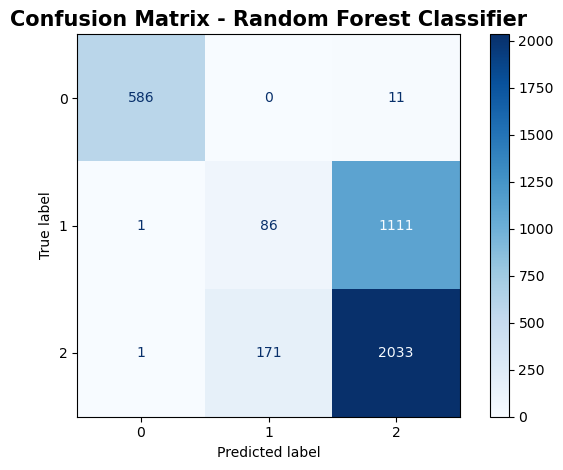

In [22]:
plt.figure(figsize=(7,6))

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=target_encoder.classes_
)

disp.plot(cmap="Blues", values_format="d")

plt.title(
    "Confusion Matrix - Random Forest Classifier",
    fontsize=15,
    fontweight="bold"
)

plt.grid(False)

plt.tight_layout()
plt.savefig("../DASHBOARD/confusion_matrix.png", dpi=300, bbox_inches="tight")

plt.show()

# Confusion Matrix

## Objective

The confusion matrix provides a detailed summary of the model's predictions by comparing the predicted labels with the actual labels.

## Why is it important?

Unlike accuracy, the confusion matrix helps identify which accident severity classes are predicted correctly and where the model makes mistakes.

## Business Insight

Understanding misclassifications is important because incorrectly predicting severe accidents as minor accidents could lead to poor decision-making in real-world road safety applications.

# Classification Report

In [16]:
print(target_encoder.classes_)
print(type(target_encoder.classes_[0]))

[0 1 2]
<class 'numpy.int64'>


In [24]:
from sklearn.metrics import classification_report
import pandas as pd

report = classification_report(
    y_test,
    y_pred,
    output_dict=True
)

report_df = pd.DataFrame(report).transpose()

report_df.to_csv(
    "../DASHBOARD/classification_report.csv",
    index=True
)

report_df

,precision,recall,f1-score,support
0,0.996599,0.981575,0.989030,597.00000
1,0.334630,0.071786,0.118213,1198.00000
2,0.644374,0.921995,0.758582,2205.00000
accuracy,0.676250,0.676250,0.676250,0.67625
macro avg,0.658534,0.658452,0.621942,4000.00000
weighted avg,0.604175,0.676250,0.601186,4000.00000


# Classification Report

## Objective

The classification report evaluates model performance using precision, recall, F1-score, and overall accuracy.

## Evaluation Metrics

### Precision
Precision measures how many predicted instances of a class are actually correct.

### Recall
Recall measures how many actual instances of a class were correctly identified.

### F1-Score
The F1-score balances precision and recall, making it a reliable metric for classification problems.

## Business Insight

Using multiple evaluation metrics provides a more comprehensive assessment of model performance than relying on accuracy alone.

# Feature Importance

In [18]:
feature_importance = pd.DataFrame({
    "Feature": X.columns,
    "Importance": rf_model.feature_importances_
})

feature_importance = feature_importance.sort_values(
    by="Importance",
    ascending=False
)

feature_importance.head(10)

,Feature,Importance
17,risk_score,0.153973
10,temperature,0.107587
2,hour,0.100136
14,casualties,0.074274
11,traffic_density,0.069356
3,day_of_week,0.064365
6,lanes,0.062537
12,cause,0.058418
0,city,0.052951
13,vehicles_involved,0.050415


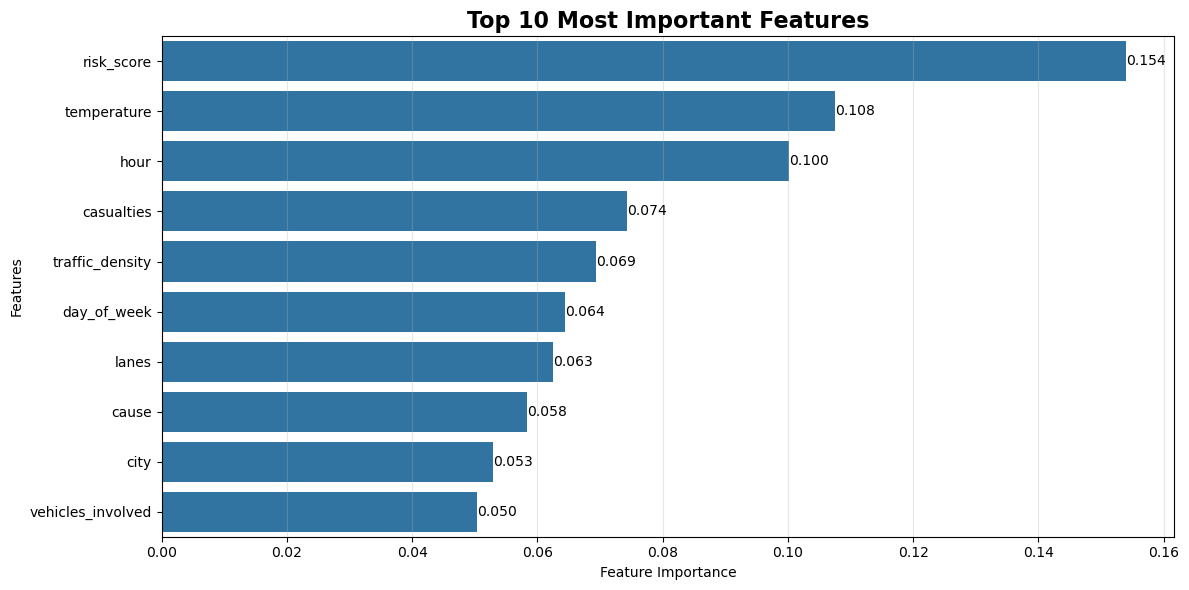

In [19]:
plt.figure(figsize=(12,6))

ax = sns.barplot(
    data=feature_importance.head(10),
    x="Importance",
    y="Feature"
)

ax.bar_label(
    ax.containers[0],
    fmt="%.3f"
)

plt.title(
    "Top 10 Most Important Features",
    fontsize=16,
    fontweight="bold"
)

plt.xlabel("Feature Importance")

plt.ylabel("Features")

plt.grid(axis="x", alpha=0.3)

plt.tight_layout()

plt.show()

# Feature Importance Analysis

## Objective

The objective of this analysis is to identify the features that contributed most to predicting accident severity.

## Observation

- Identify the top five most influential features.
- Compare their importance with less influential variables.
- Highlight any unexpected findings.

## Business Insight

Feature importance helps explain how the model makes predictions. Understanding influential variables supports better decision-making, targeted road safety measures, and future feature engineering efforts.

## Recommendation

- Prioritize the most influential factors in future road safety initiatives.
- Collect higher-quality data for important variables to further improve model performance.

In [20]:
import joblib

joblib.dump(
    rf_model,
    "../MODELS/random_forest_model.pkl"
)

['../MODELS/random_forest_model.pkl']

In [21]:
import pandas as pd

feature_importance = pd.DataFrame({
    "Feature": X_train.columns,
    "Importance": rf_model.feature_importances_
})

feature_importance = feature_importance.sort_values(
    by="Importance",
    ascending=False
)

feature_importance.to_csv(
    "../DASHBOARD/feature_importance.csv",
    index=False
)

feature_importance

,Feature,Importance
17,risk_score,0.153973
10,temperature,0.107587
2,hour,0.100136
14,casualties,0.074274
11,traffic_density,0.069356
3,day_of_week,0.064365
6,lanes,0.062537
12,cause,0.058418
0,city,0.052951
13,vehicles_involved,0.050415
